**Importing Libraries**

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)

Load Titanic Dataset

In [2]:
df = sns.load_dataset("titanic")

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Display Dataset Information

In [3]:
print("Dataset Shape:")
print(df.shape)

print()

df.info()

Dataset Shape:
(891, 15)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


Check for missing values

In [4]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


Data Cleaning:
- Remove deck column(688 missing values)

In [5]:
df.drop(columns=["deck"], inplace=True)

Fill in missing values

In [6]:
df["age"] = df["age"].fillna(df["age"].median())

df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0])

Verify cleaning

In [7]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


Select Useful Features/ predictors

In [8]:
features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]

X = df[features]

y = df["survived"]

Convert Categorical Variables

In [9]:
X = pd.get_dummies(X, drop_first=True)

X.head()

,pclass,age,sibsp,parch,fare,sex_male,embarked_Q,embarked_S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


Split the Dataset

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

Build the Model

In [11]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

Make Predictionss

In [12]:
y_pred = model.predict(X_test)

Calculate Accuracy

In [13]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8100558659217877


Calculate Precision

In [14]:
precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.7857142857142857


Calculate Recall

In [15]:
recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.7432432432432432


Calculate F1 Score

In [16]:
f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 0.7638888888888888


Generate Classification Report

In [17]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



Create Confusion Matrix

In [18]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[90 15]
 [19 55]]


Plot the Confusion Matrix

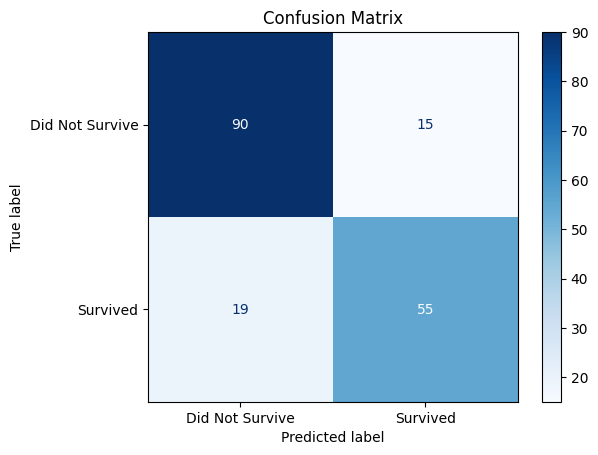

In [19]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Did Not Survive","Survived"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

Visualize Feature Importance(Model Coefficients)

In [20]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients.sort_values(
    by="Coefficient",
    ascending=False,
    inplace=True
)

coefficients

,Feature,Coefficient
4,fare,0.002591
1,age,-0.030537
3,parch,-0.108108
6,embarked_Q,-0.113105
2,sibsp,-0.295244
7,embarked_S,-0.398065
0,pclass,-0.936817
5,sex_male,-2.591503


Plot Feature Importance

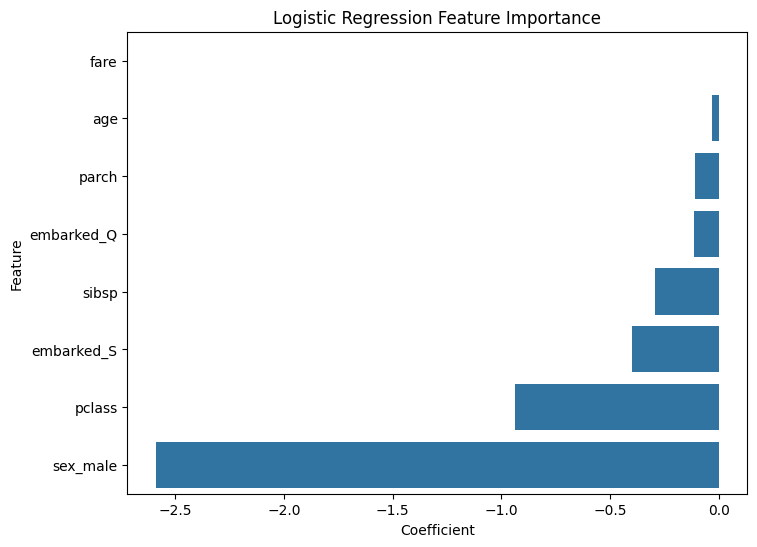

In [21]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=coefficients,
    x="Coefficient",
    y="Feature"
)

plt.title("Logistic Regression Feature Importance")

plt.show()

**Interpretation**
# Model Evaluation

Accuracy measures the percentage of correct predictions.

Precision indicates how many passengers predicted to survive actually survived.

Recall measures how many actual survivors were correctly identified.

The confusion matrix summarizes:
- True Positives
- True Negatives
- False Positives
- False Negatives

The model performs reasonably well and demonstrates that variables such as passenger class, sex, fare, and age contribute to predicting survival.

**Overfitting**

Overfitting occurs when a machine learning model learns the training data too well, including random noise and outliers.

Characteristics:
- Very high training accuracy.
- Lower testing accuracy.
- Poor performance on unseen data.

Ways to reduce overfitting:
- Use more training data.
- Remove unnecessary features.
- Apply regularization.
- Use cross-validation.
- Simplify the model.

**Underfitting**

Underfitting occurs when a model is too simple to capture patterns in the data.

Characteristics:
- Low training accuracy.
- Low testing accuracy.
- Poor predictive performance.

Ways to reduce underfitting:
- Increase model complexity.
- Engineer better features.
- Train for longer.
- Reduce excessive regularization.

Save Trained Model

In [22]:
import joblib

joblib.dump(model, "titanic_logistic_regression.pkl")

print("Model saved successfully.")

Model saved successfully.


Download Model

In [23]:
from google.colab import files

files.download("titanic_logistic_regression.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>